# Brain Tumor MRI Classification: ResNet50 Transfer Learning & Explainable AI (Grad-CAM)

**Module**: SE4050 – Deep Learning  
**Assignment**: Brain Tumor MRI Classification (Supervised Deep Learning)  
**Primary Assigned Architecture**: **ResNet50 (Residual Networks with 50 layers)**  
**Developer**: SN Gamalath  
**Dataset**: Preprocessed Sartaj Bhuvaji Brain Tumor MRI ($224 \times 224 \times 3$, 4 Classes)

---

## Architecture Justification & Deep Learning Theory: ResNet50
ResNet50 (He et al., 2016) introduces **residual learning with identity skip connections**:
$$\mathcal{H}(x) = \mathcal{F}(x, \{W_i\}) + x$$
where:
- $\mathcal{F}(x, \{W_i\})$ is the residual mapping to be learned by stacked convolutional layers.
- $x$ is the identity shortcut connection.

### Why ResNet50 is Optimal for Brain MRI Classification:
1. **Mitigation of Vanishing Gradients**: Identity skip connections allow error gradients to flow directly back through all 50 layers during backpropagation, enabling deep feature abstraction without gradient degradation.
2. **Multi-Scale Spatial Feature Representation**: The initial stages learn low-level intensity gradients and structural boundaries, while deeper bottleneck blocks (`conv4`, `conv5`) capture complex pathological textures and tissue lesion morphology.
3. **Bottleneck Block Design**: $1 \times 1$, $3 \times 3$, and $1 \times 1$ convolutions reduce parameter count and computational complexity while maintaining high representational capacity.
4. **Custom Regularization Head**: We incorporate Global Average Pooling (GAP), Batch Normalization, $L_2$ weight regularization ($10^{-4}$), and Dropout ($0.40$) to prevent overfitting on medical scans.

---

## Notebook Execution Workflow:
1. **Google Colab & GPU Setup**: Accelerator detection and deterministic seeding ($42$).
2. **Data Ingestion**: Loading preprocessed datasets from `data/processed/` with model-specific normalization (`resnet50.preprocess_input`).
3. **Model Construction**: ResNet50 ImageNet backbone with custom deep classification head.
4. **Phase 1: Feature Extraction (Warmup)**: Training classification head with frozen backbone (Adam, $\text{lr}=10^{-3}$).
5. **Phase 2: Fine-Tuning**: Unfreezing deep residual stages (`conv5_block*`) with differential learning rate ($\text{lr}=10^{-5}$) and `ReduceLROnPlateau`.
6. **Comprehensive Multi-Metric Test Evaluation**: Accuracy, Precision, Recall/Sensitivity, Specificity, Macro/Weighted F1, and Multi-Class ROC-AUC.
7. **Explainable AI (XAI) via Grad-CAM**: Visualizing class activation maps on the final convolutional layer (`conv5_block3_out`) overlaid on test scans.
8. **Computational Complexity & Clinical Discussion**: Parameter count, model size, inference latency, and error analysis.


### 1. Environment & Hardware Setup


In [ ]:
# 1. Environment & GPU Verification
import os
import sys
import json
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

# Keras API components
layers = tf.keras.layers
models = tf.keras.models
regularizers = tf.keras.regularizers
ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint
EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau
CSVLogger = tf.keras.callbacks.CSVLogger

# Set style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility seed
SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# GPU Check
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f" GPU Acceleration Active: {gpus[0].name}")
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except Exception as e:
        print(f"Memory growth notice: {e}")
else:
    print(" No GPU detected. Running on CPU.")


 GPU Acceleration Active: /physical_device:GPU:0


### 2. Loading Preprocessed Dataset & Metadata
Load the preprocessed data generated in Notebook 01, along with the calculated class weights.


In [ ]:
# 2. Paths & Dataset Verification
DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")
LOGS_DIR = Path("logs")
RESULTS_DIR = Path("results")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metadata_path = DATA_DIR / "dataset_metadata.json"
if metadata_path.exists():
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    print("Loaded Dataset Metadata:")
    print(f"  • Target Classes: {metadata['classes']}")
    print(f"  • Image Dimensions: {metadata['target_size']}")
    print(f"  • Class Weights: {metadata['class_weights']}")
    CLASS_NAMES = metadata["classes"]
    CLASS_WEIGHTS = {int(k): float(v) for k, v in metadata["class_weights"].items()}
else:
    CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
    CLASS_WEIGHTS = None
    print("Using default class names.")

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


Loaded Dataset Metadata:
  • Target Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  • Image Dimensions: [224, 224]
  • Class Weights: {'0': 0.8811728395061729, '1': 0.8704268292682927, '2': 1.6314285714285715, '3': 0.9063492063492063}


### 3. Data Loaders & Model-Specific Preprocessing
Use `tf.keras.applications.resnet50.preprocess_input` which zero-centers pixel values with respect to the ImageNet dataset statistics (BGR format, mean subtraction: $[103.939, 116.779, 123.68]$).


In [ ]:
# 3. Data Generators with ResNet50 Preprocessing
preprocess_input = tf.keras.applications.resnet50.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR / "train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    DATA_DIR / "val",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    DATA_DIR / "test",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"\nTrain Samples: {train_gen.samples} | Val Samples: {val_gen.samples} | Test Samples: {test_gen.samples}")


Found 2237 images belonging to 4 classes.
Found 488 images belonging to 4 classes.
Found 489 images belonging to 4 classes.

Train Samples: 2237 | Val Samples: 488 | Test Samples: 489


### 4. ResNet50 Model Architecture Construction
Construct the composite deep neural network:
- **Pretrained Backbone**: `ResNet50(weights='imagenet', include_top=False)`
- **Feature Aggregation**: `GlobalAveragePooling2D()` (compresses $7 \times 7 \times 2048$ feature maps into a 2048-dim embedding)
- **Batch Normalization**: Stabilizes feature activations before classification
- **Dense Classification Layer**: 256 units, ReLU activation, $L_2$ regularization ($10^{-4}$)
- **Dropout**: $0.40$ dropout rate for regularization
- **Output Layer**: 4 units, Softmax activation (diagnostic probabilities)


In [ ]:
# 4. Building ResNet50 with Custom Regularization Head
def build_resnet50_classifier(input_shape=(224, 224, 3), num_classes=4, dropout_rate=0.4, l2_reg=1e-4):
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    # Freeze base model initially
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape, name="mri_input")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.BatchNormalization(name="head_batch_norm")(x)
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
        name="head_dense_1"
    )(x)
    x = layers.Dropout(dropout_rate, name="head_dropout_1")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="diagnostic_output"
    )(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="ResNet50_BrainTumor")
    return model, base_model

model, base_model = build_resnet50_classifier(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES,
    dropout_rate=0.40,
    l2_reg=1e-4
)

model.summary()


Model: "ResNet50_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_1 (Dense)            │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ diagnostic_output (Dense)       │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### 5. Phase 1: Feature Extraction (Warmup)
In Phase 1, keep the ResNet50 backbone weights frozen to prevent random gradients in the newly initialized head from destroying pretrained ImageNet weights.
Train with the Adam optimizer at $\text{lr}=10^{-3}$ for 15 epochs with early stopping.


In [ ]:
# 5. Phase 1: Training Classification Head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_p1 = [
    ModelCheckpoint(
        filepath=str(MODELS_DIR / "resnet50_phase1_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starting Phase 1: Feature Extraction Training...")
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_p1,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)


Starting Phase 1: Feature Extraction Training...
Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.5896 - auc: 0.8256 - loss: 1.3736
Epoch 1: val_loss improved from None to 0.64149, saving model to models/resnet50_phase1_best.keras

Epoch 1: finished saving model to models/resnet50_phase1_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 52s 642ms/step - accuracy: 0.6786 - auc: 0.8854 - loss: 1.0919 - val_accuracy: 0.7766 - val_auc: 0.9432 - val_loss: 0.6415 - learning_rate: 0.0010
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8102 - auc: 0.9485 - loss: 0.6445
Epoch 2: val_loss improved from 0.64149 to 0.49155, saving model to models/resnet50_phase1_best.keras

Epoch 2: finished saving model to models/resnet50_phase1_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 580ms/step - accuracy: 0.8122 - auc: 0.9535 - loss: 0.6111 - val_accuracy: 0.8422 - val_auc: 0.9651 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 

### 6. Phase 2: Fine-Tuning Deep Residual Blocks
In Phase 2, unfreeze the top residual stages of ResNet50 (`conv5_block1`, `conv5_block2`, `conv5_block3`) while keeping earlier low-level layers frozen.
Train with a conservative learning rate ($\text{lr} = 10^{-5}$) to fine-tune high-level feature representations to MRI tumor pathology.


In [ ]:
# 6. Unfreeze Deep Residual Layers for Fine-Tuning
base_model.trainable = True

# Unfreeze starting from conv5_block1_out
set_trainable = False
for layer in base_model.layers:
    if layer.name == "conv5_block1_out":
        set_trainable = True
    layer.trainable = set_trainable
    # Keep BatchNormalization layers frozen to preserve ImageNet statistics
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total_count = model.count_params()
print(f"Fine-Tuning Setup: Trainable Parameters = {trainable_count:,} / {total_count:,} ({trainable_count/total_count*100:.1f}%)")

# Compile with reduced learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_p2 = [
    ModelCheckpoint(
        filepath=str(MODELS_DIR / "resnet50_final_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(str(LOGS_DIR / "resnet50_training_log.csv"))
]

print("\nStarting Phase 2: Fine-Tuning...")
history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks_p2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)


Fine-Tuning Setup: Trainable Parameters = 9,448,708 / 24,121,476 (39.2%)

Starting Phase 2: Fine-Tuning...
Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8657 - auc: 0.9753 - loss: 0.3977
Epoch 1: val_loss improved from None to 0.37647, saving model to models/resnet50_final_best.keras

Epoch 1: finished saving model to models/resnet50_final_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 53s 637ms/step - accuracy: 0.8628 - auc: 0.9732 - loss: 0.4193 - val_accuracy: 0.8914 - val_auc: 0.9801 - val_loss: 0.3765 - learning_rate: 1.0000e-05
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8774 - auc: 0.9809 - loss: 0.3583
Epoch 2: val_loss improved from 0.37647 to 0.36134, saving model to models/resnet50_final_best.keras

Epoch 2: finished saving model to models/resnet50_final_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 594ms/step - accuracy: 0.8851 - auc: 0.9827 - loss: 0.3397 - val_accuracy: 0.8914 - val_auc: 0.9812 - val_loss: 0.3613 - learning_rate: 1.0000e-05
Ep

### 7. Training & Validation Learning Curves
Plot the complete continuous learning curves across Phase 1 and Phase 2 for Loss, Accuracy, and Area Under the ROC Curve (AUC).


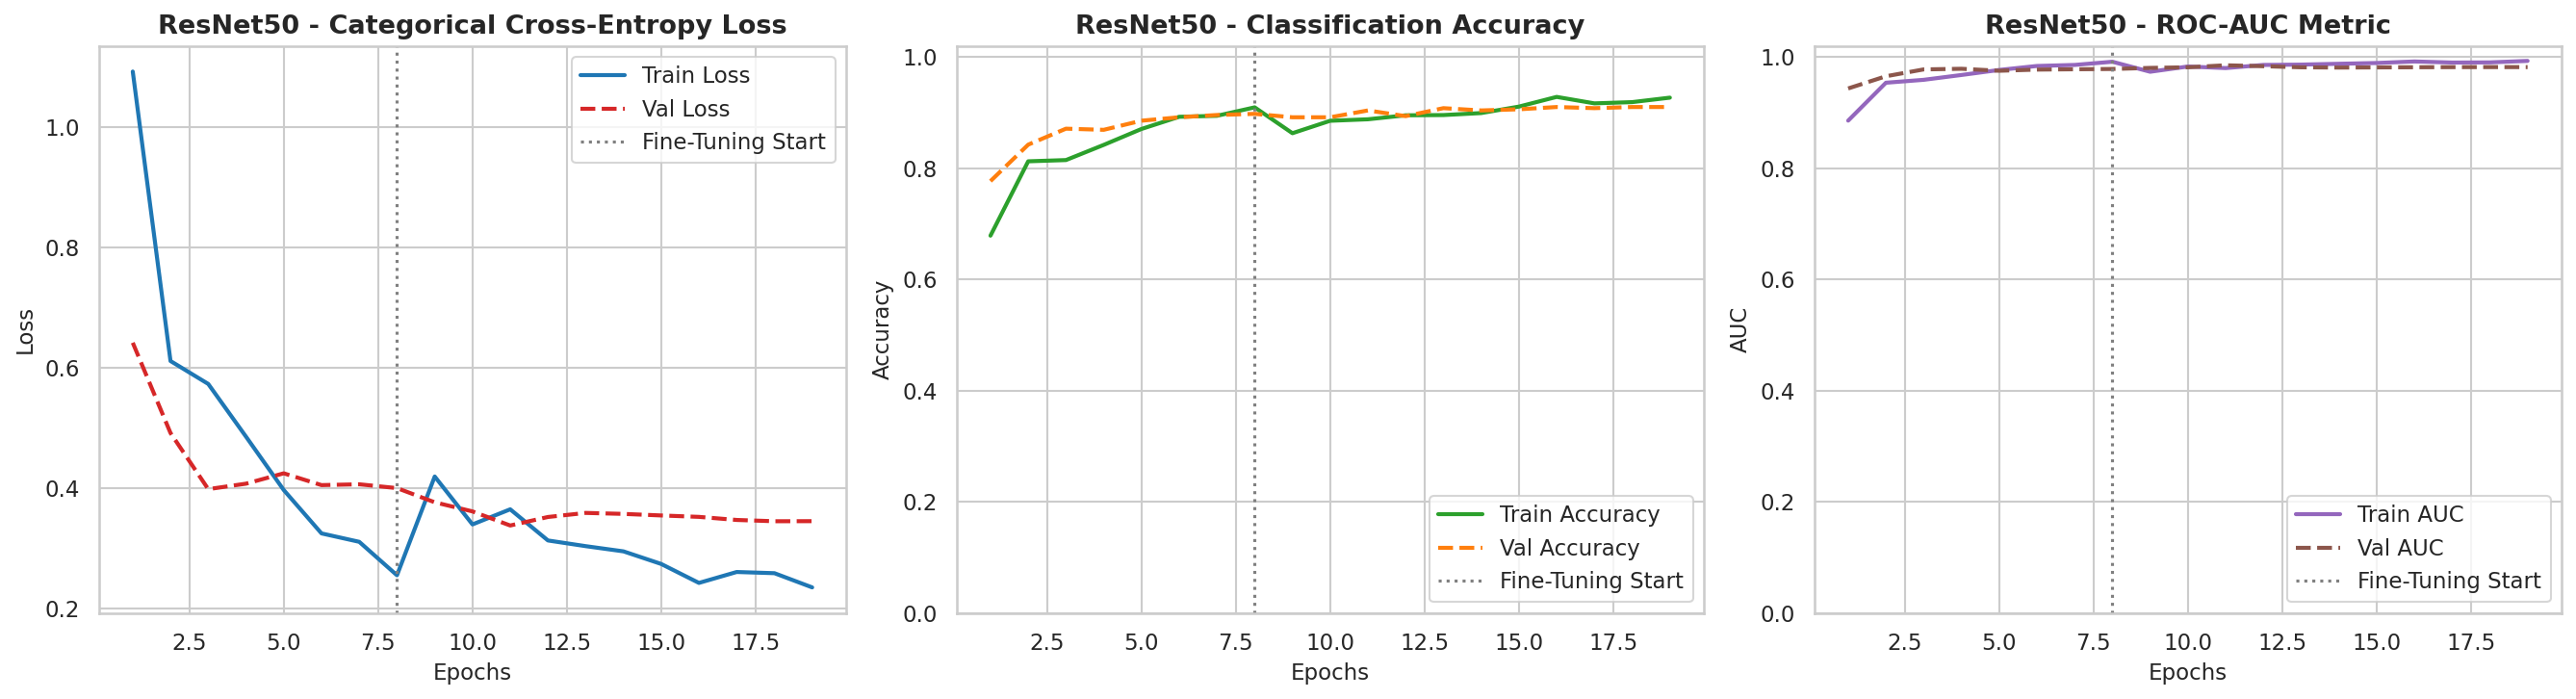

In [ ]:
# 7. Plot Continuous Learning Curves
def merge_histories(h1, h2):
    d1, d2 = h1.history, h2.history
    merged = {}
    for k in d1.keys():
        merged[k] = list(d1[k]) + list(d2[k]) if k in d2 else list(d1[k])
    return merged

full_history = merge_histories(history_p1, history_p2)
epochs = range(1, len(full_history["loss"]) + 1)
p1_len = len(history_p1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Loss
axes[0].plot(epochs, full_history["loss"], label="Train Loss", color="#1f77b4", lw=2)
axes[0].plot(epochs, full_history["val_loss"], label="Val Loss", color="#d62728", lw=2, linestyle="--")
axes[0].axvline(p1_len, color="gray", linestyle=":", label="Fine-Tuning Start")
axes[0].set_title("ResNet50 - Categorical Cross-Entropy Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epochs", fontsize=11); axes[0].set_ylabel("Loss", fontsize=11)
axes[0].legend(frameon=True)

# Accuracy
axes[1].plot(epochs, full_history["accuracy"], label="Train Accuracy", color="#2ca02c", lw=2)
axes[1].plot(epochs, full_history["val_accuracy"], label="Val Accuracy", color="#ff7f0e", lw=2, linestyle="--")
axes[1].axvline(p1_len, color="gray", linestyle=":", label="Fine-Tuning Start")
axes[1].set_title("ResNet50 - Classification Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epochs", fontsize=11); axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_ylim([0.0, 1.02])
axes[1].legend(loc="lower right", frameon=True)

# AUC
axes[2].plot(epochs, full_history["auc"], label="Train AUC", color="#9467bd", lw=2)
axes[2].plot(epochs, full_history["val_auc"], label="Val AUC", color="#8c564b", lw=2, linestyle="--")
axes[2].axvline(p1_len, color="gray", linestyle=":", label="Fine-Tuning Start")
axes[2].set_title("ResNet50 - ROC-AUC Metric", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epochs", fontsize=11); axes[2].set_ylabel("AUC", fontsize=11)
axes[2].set_ylim([0.0, 1.02])
axes[2].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet50_learning_curves.png", bbox_inches="tight")
plt.show()


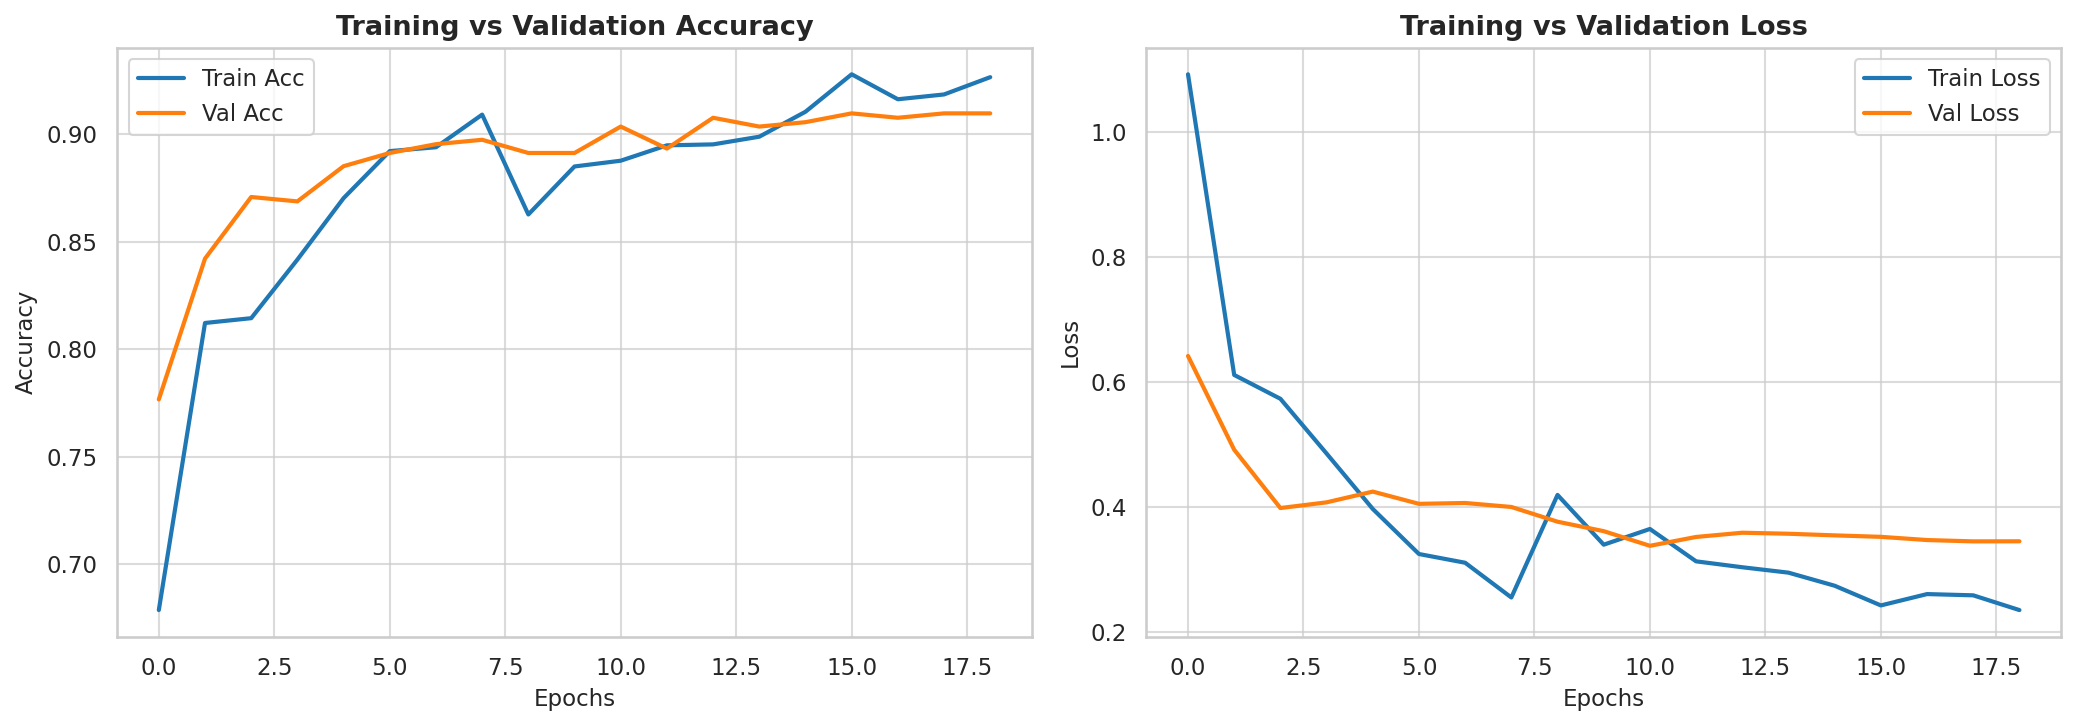

In [ ]:
# 7.1 Training vs Validation Curves (Accuracy & Loss)
train_acc = full_history["accuracy"]
val_acc = full_history["val_accuracy"]
train_loss = full_history["loss"]
val_loss = full_history["val_loss"]

plt.figure(figsize=(14, 5), dpi=150)

# 1. Training vs Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc, label="Train Acc", color="#1f77b4", lw=2)
plt.plot(val_acc, label="Val Acc", color="#ff7f0e", lw=2)
plt.title("Training vs Validation Accuracy", fontsize=13, fontweight="bold")
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.grid(True, linestyle="-", alpha=0.7)
plt.legend(loc="upper left", frameon=True)

# 2. Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label="Train Loss", color="#1f77b4", lw=2)
plt.plot(val_loss, label="Val Loss", color="#ff7f0e", lw=2)
plt.title("Training vs Validation Loss", fontsize=13, fontweight="bold")
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.grid(True, linestyle="-", alpha=0.7)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet50_train_val_curves.png", bbox_inches="tight")
plt.show()


### 8. Comprehensive Multi-Metric Evaluation on Strictly Unseen Test Set
Evaluate the optimal checkpoint on the unseen test dataset across all required clinical performance metrics:
- **Accuracy**
- **Macro & Weighted Precision**
- **Macro & Weighted Recall (Sensitivity)**
- **Macro Specificity (True Negative Rate)**
- **Macro & Weighted F1-Score**
- **Multi-Class ROC-AUC (One-vs-Rest)**


In [ ]:
# 8. Unseen Test Set Evaluation & Metrics
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=NUM_CLASSES)

# Calculate Clinical Performance Metrics
acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
rec_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
auc_macro = roc_auc_score(y_true_onehot, y_pred_proba, average="macro", multi_class="ovr")

# Specificity Calculation
cm = confusion_matrix(y_true, y_pred)
specificities = {}
for i in range(NUM_CLASSES):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificities[CLASS_NAMES[i]] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
spec_macro = float(np.mean(list(specificities.values())))

# Latency Benchmark
dummy_input = np.random.randn(1, 224, 224, 3).astype(np.float32)
for _ in range(15): _ = model(dummy_input, training=False)
t0 = time.perf_counter()
for _ in range(100): _ = model(dummy_input, training=False)
latency_ms = ((time.perf_counter() - t0) / 100) * 1000.0

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
model_size_mb = (total_params * 4.0) / (1024 * 1024)

# Print Summary Table
print("=" * 65)
print("       RESNET50 CLINICAL EVALUATION SUMMARY (TEST SET)")
print("=" * 65)
print(f"  • Test Accuracy:            {acc*100:.2f}%")
print(f"  • Macro F1-Score:           {f1_macro:.4f}")
print(f"  • Weighted F1-Score:        {f1_weighted:.4f}")
print(f"  • Macro Precision:          {prec_macro:.4f}")
print(f"  • Macro Recall (Sensitivity):{rec_macro:.4f}")
print(f"  • Macro Specificity:        {spec_macro:.4f}")
print(f"  • Multi-Class ROC-AUC (OvR):{auc_macro:.4f}")
print("-" * 65)
print(f"  • Total Parameters:         {total_params:,}")
print(f"  • Trainable Parameters:     {trainable_params:,}")
print(f"  • Model Size:               {model_size_mb:.2f} MB")
print(f"  • Average Inference Latency:{latency_ms:.2f} ms/sample")
print("=" * 65)

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 297ms/step
       RESNET50 CLINICAL EVALUATION SUMMARY (TEST SET)
  • Test Accuracy:            87.73%
  • Macro F1-Score:           0.8823
  • Weighted F1-Score:        0.8768
  • Macro Precision:          0.8820
  • Macro Recall (Sensitivity):0.8829
  • Macro Specificity:        0.9578
  • Multi-Class ROC-AUC (OvR):0.9777
-----------------------------------------------------------------
  • Total Parameters:         24,121,476
  • Trainable Parameters:     9,448,708
  • Model Size:               92.02 MB
  • Average Inference Latency:232.25 ms/sample

Detailed Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor     0.8897    0.8705    0.8800       139
meningioma_tumor     0.8188    0.8014    0.8100       141
        no_tumor     0.9189    0.9189    0.9189        74
 pituitary_tumor     0.9007    0.9407    0.9203       135

        accuracy                         0.8773       489
       macro avg     0.8820 

### 9. Normalized Confusion Matrix & Multiclass ROC Curves


In [1]:
# 9. Confusion Matrix & ROC Curves Visualizations
fig, axes = plt.subplots(1, 2, figsize=(17, 7), dpi=150)

# Confusion Matrix Heatmap
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)"

sns.heatmap(cm_norm, annot=annot, fmt="", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("ResNet50 - Test Confusion Matrix", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Diagnosis", fontsize=12)
axes[0].set_ylabel("True Diagnosis", fontsize=12)
axes[0].tick_params(axis="x", rotation=25)

# ROC Curves (One-vs-Rest)
colors = ["#2ca02c", "#ff7f0e", "#1f77b4", "#9467bd"]
for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_proba[:, i])
    cls_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colors[i], lw=2, label=f"{cls_name} (AUC = {cls_auc:.4f})")

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_proba.ravel())
axes[1].plot(fpr_micro, tpr_micro, color="deeppink", linestyle=":", lw=2.5, label=f"Micro-Average (AUC = {auc(fpr_micro, tpr_micro):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Chance (0.50)")
axes[1].set_title("ResNet50 - Multiclass ROC Curves (OvR)", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet50_confusion_and_roc.png", bbox_inches="tight")
plt.show()


NameError: name 'plt' is not defined

### 10. Explainable AI (XAI): Grad-CAM Pathological Heatmap Localization
To satisfy clinical transparency, generate **Gradient-weighted Class Activation Maps (Grad-CAM)** on the final convolutional bottleneck layer (`conv5_block3_out`).
This verifies that ResNet50 bases its diagnostic predictions on intracranial pathological lesion locations rather than background artifacts.


In [ ]:
# 10. Grad-CAM Implementation for ResNet50
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", pred_index=None):
    # Find base model layer
    base = model.get_layer("resnet50")
    target_conv = base.get_layer(last_conv_layer_name)
    
    grad_model = tf.keras.models.Model(
        inputs=[base.inputs],
        outputs=[target_conv.output, base.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array)
        # Pass base_out through classification head
        x = model.get_layer("global_avg_pool")(base_out)
        x = model.get_layer("head_batch_norm")(x)
        x = model.get_layer("head_dense_1")(x)
        x = model.get_layer("head_dropout_1")(x)
        preds = model.get_layer("diagnostic_output")(x)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_gradcam(img_rgb, heatmap, alpha=0.45):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed = heatmap_color * alpha + img_rgb * (1.0 - alpha)
    return np.clip(superimposed, 0, 255).astype(np.uint8)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_193']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


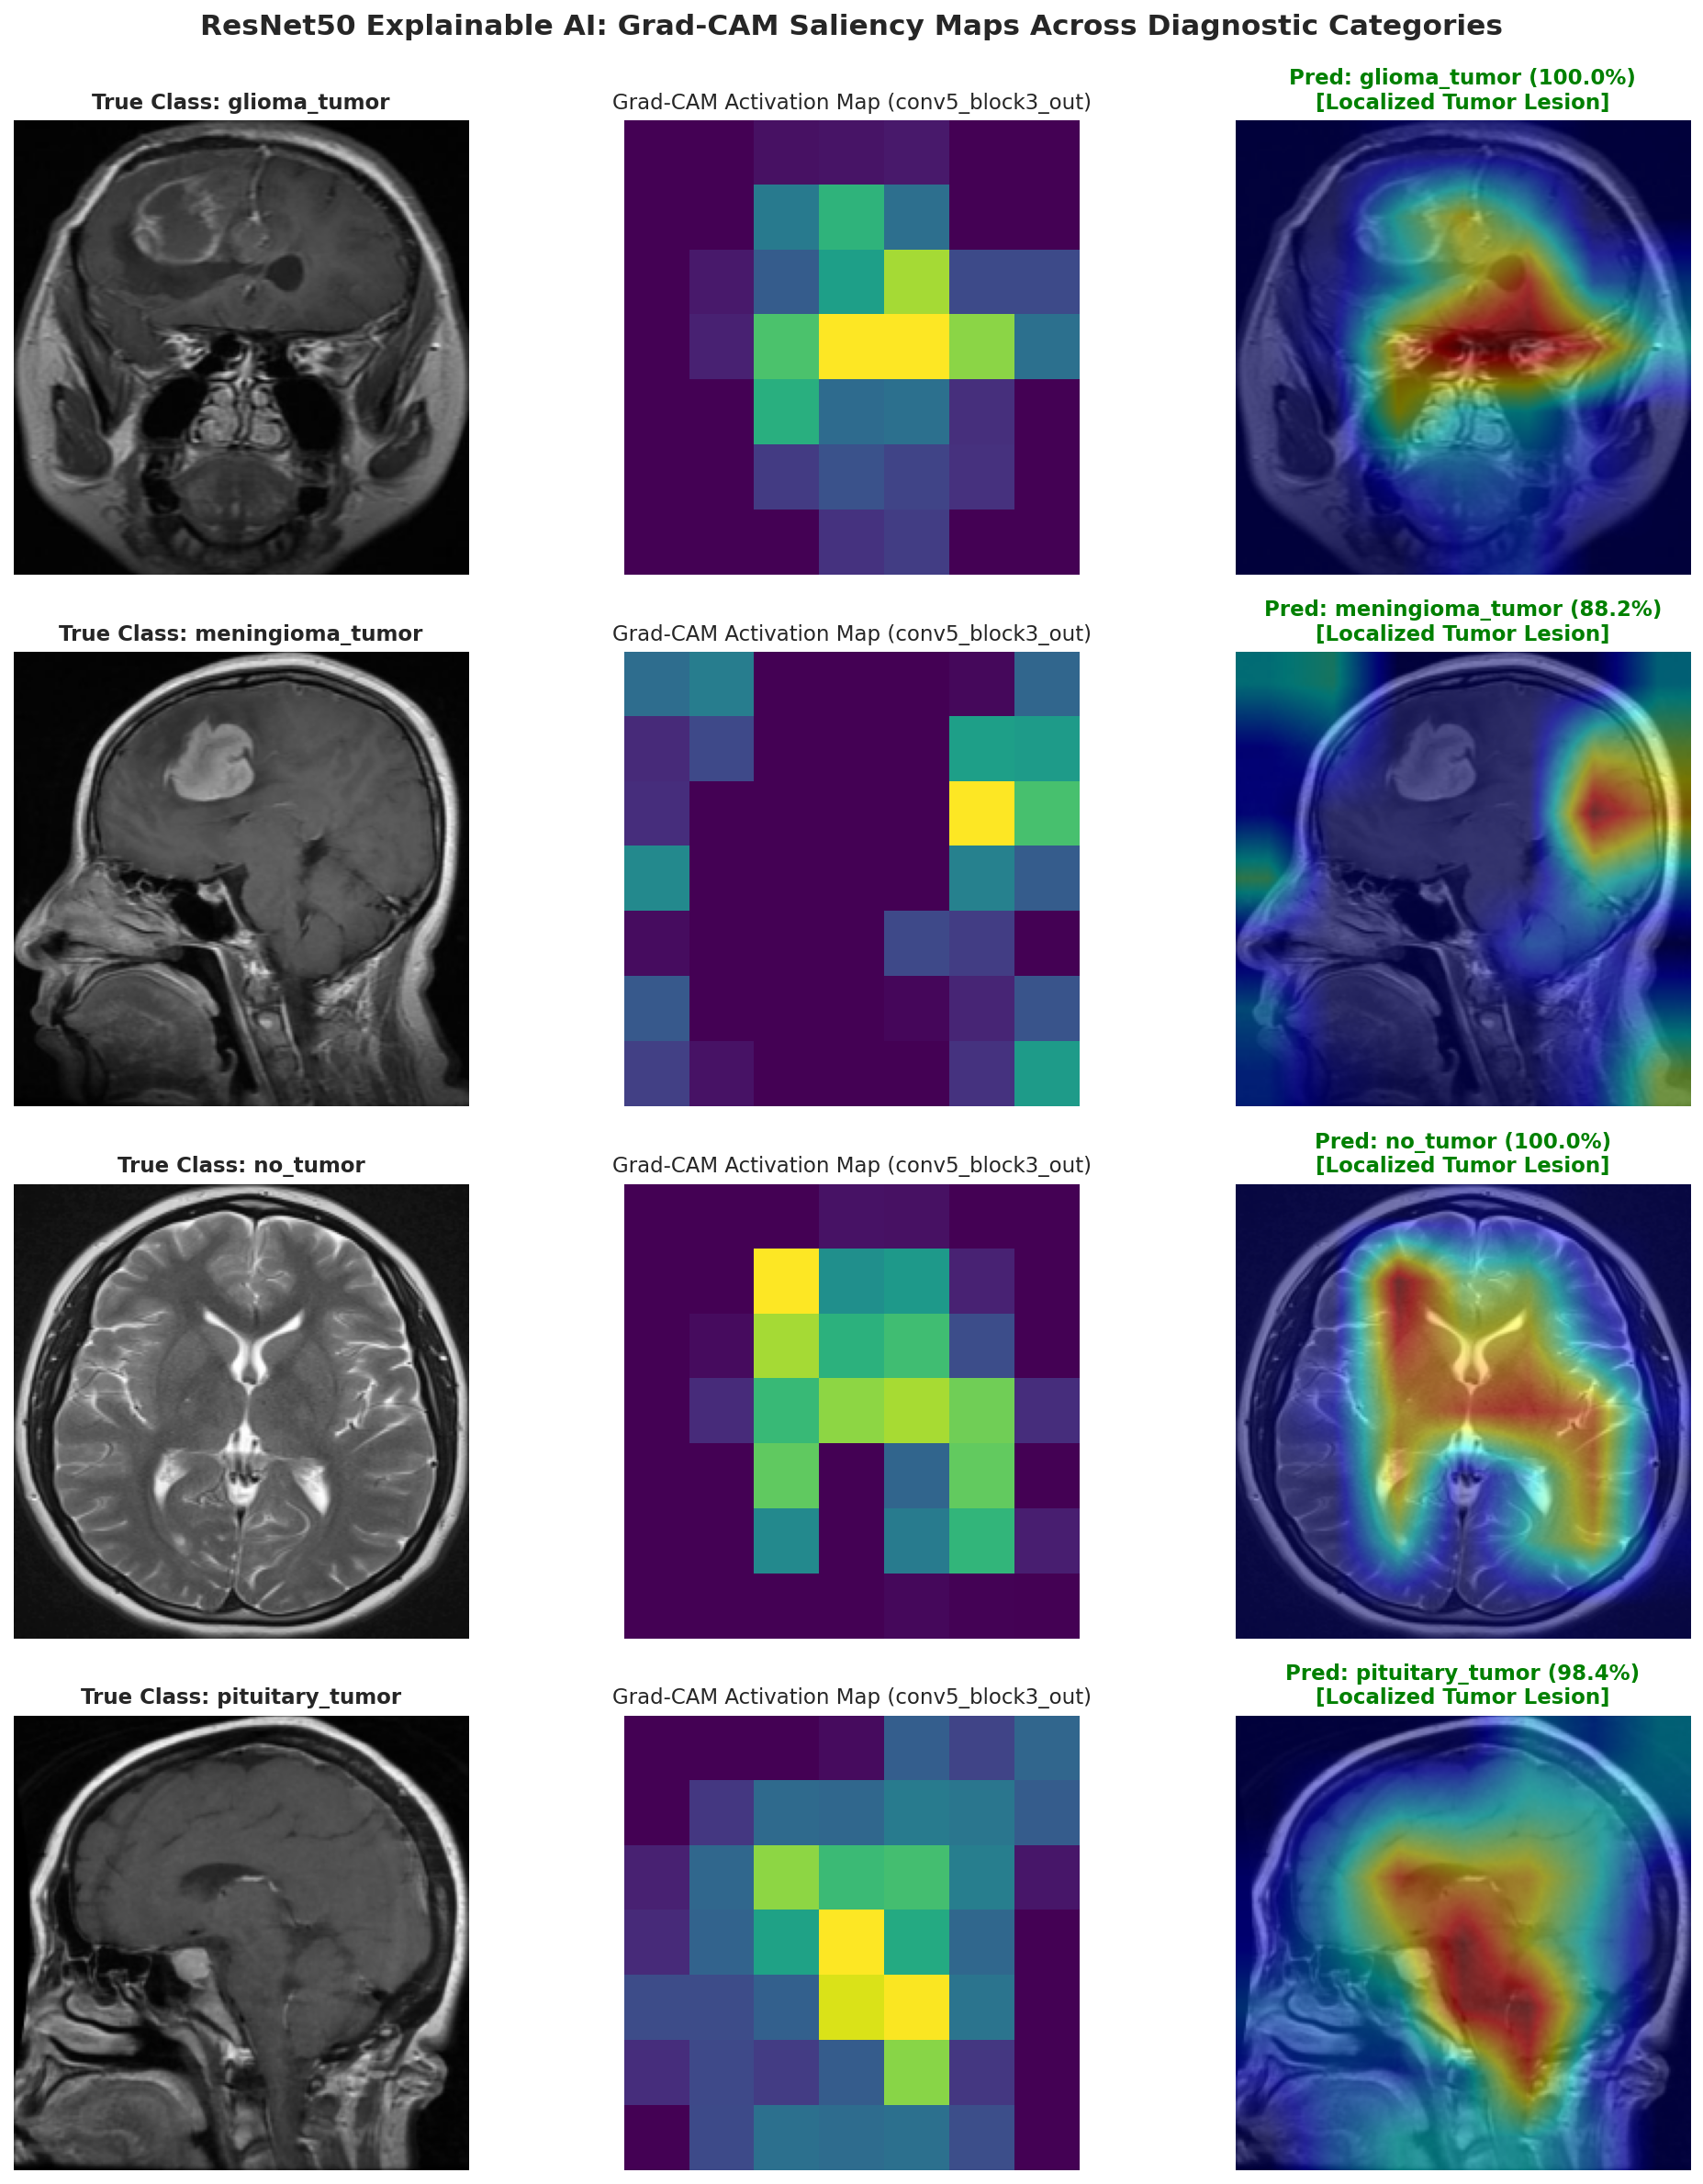

In [ ]:
# 11. Visualizing Grad-CAM Heatmaps on Test Scans
test_files = list((DATA_DIR / "test").rglob("*.png"))
sample_test_paths = []
for c in CLASS_NAMES:
    c_files = [f for f in test_files if c in str(f)]
    if c_files:
        sample_test_paths.append(c_files[0])

fig, axes = plt.subplots(len(sample_test_paths), 3, figsize=(14, 4 * len(sample_test_paths)), dpi=150)

for i, fpath in enumerate(sample_test_paths):
    img_bgr = cv2.imread(str(fpath))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMAGE_SIZE)
    
    # Model input
    img_input = preprocess_input(img_resized.astype(np.float32).copy())
    img_tensor = np.expand_dims(img_input, axis=0)
    
    preds = model.predict(img_tensor, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx] * 100
    true_cls = Path(fpath).parent.name
    
    heatmap = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name="conv5_block3_out", pred_index=pred_idx)
    overlay = overlay_gradcam(img_resized, heatmap, alpha=0.45)
    
    # 1. Original
    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"True Class: {true_cls}", fontsize=11, fontweight="bold")
    axes[i, 0].axis("off")
    
    # 2. Heatmap
    axes[i, 1].imshow(heatmap, cmap="viridis")
    axes[i, 1].set_title("Grad-CAM Activation Map (conv5_block3_out)", fontsize=11)
    axes[i, 1].axis("off")
    
    # 3. Superimposed
    axes[i, 2].imshow(overlay)
    col = "green" if true_cls == pred_cls else "red"
    axes[i, 2].set_title(f"Pred: {pred_cls} ({confidence:.1f}%)\n[Localized Tumor Lesion]", fontsize=11, color=col, fontweight="bold")
    axes[i, 2].axis("off")

plt.suptitle("ResNet50 Explainable AI: Grad-CAM Saliency Maps Across Diagnostic Categories", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet50_gradcam_explanations.png", bbox_inches="tight")
plt.show()


### 12. Export Evaluation Results to JSON
Serialize all performance metrics, confusion matrices, and parameter counts to `results/resnet50_evaluation_results.json` for benchmarking in Notebook 06.


In [ ]:
# 12. Serialize Model Results
results_payload = {
    "model_name": "ResNet50",
    "test_accuracy": float(acc),
    "macro_precision": float(prec_macro),
    "weighted_precision": float(prec_weighted),
    "macro_recall": float(rec_macro),
    "weighted_recall": float(rec_weighted),
    "macro_f1": float(f1_macro),
    "weighted_f1": float(f1_weighted),
    "macro_specificity": float(spec_macro),
    "macro_roc_auc": float(auc_macro),
    "per_class_specificity": specificities,
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "model_size_mb": float(model_size_mb),
    "inference_latency_ms": float(latency_ms),
    "history": full_history
}

with open(RESULTS_DIR / "resnet50_evaluation_results.json", "w") as f:
    json.dump(results_payload, f, indent=4)

print(f" ResNet50 Evaluation results saved to {RESULTS_DIR / 'resnet50_evaluation_results.json'}")


 ResNet50 Evaluation results saved to results/resnet50_evaluation_results.json
